# 1.7 RBC Model in Julia

The algorithm is the same as that in MATLAB and Python case. 

## Import modules

In [ ]:
println(pwd())

C:\Users\ading\A_TA_Notes


In [ ]:
cd("C:/Users/ading/A_TA_Notes")

In [ ]:
push!(LOAD_PATH,"")
using Parameters, ModelUtils

It seems that Julia doesn't have command like "clear all" in MATLAB, so when I re-run a script after adjustment, I usually meet some variable contradiction problems. What I can do up to now, is to restart the program..

I use module ModelUtils, which is written by Professor Alisdair Mckay.

## Parameters

To input Greek letters, first type "\alpha" on the keyboard and then press Tab.

In [ ]:
# parameters
@with_kw struct Par 
    α = 0.35
    β = 0.99
    γ = 1.0
    δ = 0.025
    ρ = 0.95
    ϕ = 7.8
    η = 1.0
end
par = Par();

@endogenousvariables A R N K Y C I W
@exogenousvariables ε

VarsExog

## Steady state

In [ ]:
# steady state
function get_ss(par)
    @unpack α, β, γ, δ = par
    A = 1.
    R = 1 / β - 1 + δ
    N = 1/3
    K = N*((R/A/α))^(1/(α-1))
    Y = A*K^α*N^(1-α)
    C = Y - δ*K
    I = δ*K
    W = (1-α)*Y/N
    return [A; R; N; K; Y; C; I; W]
end
steadystate= Dict("initial" => get_ss(par), "exog" => [0.]);
print(steadystate);

Dict("initial" => [1.0, 0.03510101010101017, 0.3333333333333333, 11.466075350722265, 1.14991664772756, 0.8632647639595032, 0.28665188376805667, 2.242337463068742], "exog" => [0.0])

In [ ]:
# Create model environment
m = ModelEnv(par=par,vars=vardict,steadystate=steadystate,T=100);

## Equilibrium system

Note that, .* operator is used for element-wise multiplication of arrays. It multiplies corresponding elements of the arrays.

And * operator is used for standard matrix multiplication. It follows the rules of linear algebra for multiplying matrices.

In [ ]:
function f(m::ModelEnv,X,E)
    
    @unpack A, R, N, K, Y, C, I, W = contemp(X,m)
    @unpack A_p, R_p, N_p, K_p, Y_p, C_p, I_p, W_p = lead(X,m)
    @unpack A_l, R_l, N_l, K_l, Y_l, C_l, I_l, W_l = lag(X,m)    
    @unpack ε = exogenous(E,m)
    @unpack α, β, γ, δ, ρ, ϕ, η = m.par
    
    return [-C.^(-γ) .+ β * (R .- δ .+ 1) .* C_p.^(-γ);
            ϕ * N.^(1/η) .- W.*C.^(-γ);            
            -Y .+ A .* K_l.^α .*N.^(1-α);
            α * A .* K_l.^(α-1).*N.^(1-α) .- R;
            (1-α)*A.*K_l.^α.*N.^(-α) .- W;
            (1-δ)*K_l .+ I_l .- K;
            Y .- C .- I;
            -log.(A) .+ ρ .* log.(A_l) .+ ε]    
end

f (generic function with 1 method)

## Plot

In [ ]:
# setup the shock
Xss,E = longsteadystate(m);
E[1] = 0.01; # 1% shock to TFP at date 0

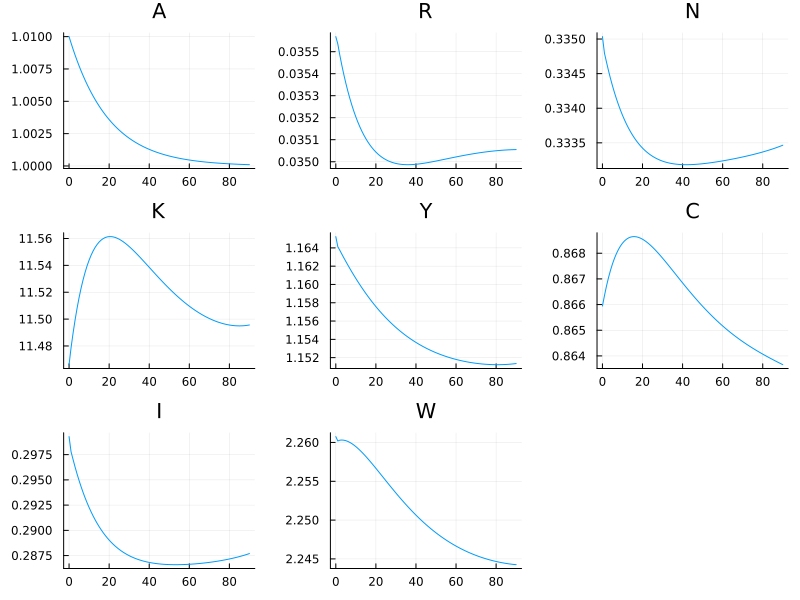

In [ ]:
# linear solution
Xlin = Xss + linearIRFs(f,m) * E;
display( plot(Xlin,m) )